# Jaatinen HSC-up Stage 2 Probe

Question: is `JAATINEN_HEMATOPOIETIC_STEM_CELL_UP` only confirming that malignant MRD cells are CD34+/HSC-like, or does it reveal malignant-specific, patient-recurrent primitive/quiescent/inflammatory stem-like programs?

This notebook starts from the completed Stage 0, Stage 1, and quick Stage 2 artifacts referenced in `jaatinen_hsc_up_quick_stage2_context.md`.

Key controls implemented here:

- Compare all 16 quick Stage 2 representations to decide whether the saved quick result is a screen or enough evidence.
- Recompute strict leave-one-patient-out (LOPO) models from saved `scores.npy`, because quick Stage 2 used 5-fold `GroupKFold` and several folds held out multiple patients together.
- Compare Jaatinen factors against `predicted.annotation` only, annotation-residualized factors, and within HSC/MPP-like cells.
- Compute per-patient factor usage deltas and Cliff's delta, aligned with the manuscript-style cNMF program-usage comparison.
- Summarize coefficient sign stability and factor recurrence across patients.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

EXPERIMENT_ROOT = Path(
    "/home/minhang/mds_project/sc_classification/experiments/"
    "20260525_060508_stage0_mrd_old34_broad_screen_82db5093"
)
BRANCH = "expanded_stage0_mrd_manuscript_axes_v1"
PANEL_ID = "atomic_hspc_lsc_stemness_hsc_mpp_lsc_jaatinen_hematopoietic_stem_cell_up"
INPUT_H5AD = Path("/home/minhang/mds_project/data/cohort_adata/adata_cellType_cnLabel_pseudoTime_collectionTime.h5ad")

STAGE1_ROOT = EXPERIMENT_ROOT / "stage1_dr" / BRANCH / f"panel_id={PANEL_ID}"
STAGE2_ROOT = EXPERIMENT_ROOT / "stage2_supervised" / "shared_cross_patient" / BRANCH / f"panel_id={PANEL_ID}"
ANNOTATION_PATH = (
    EXPERIMENT_ROOT
    / "preprocessing"
    / "panels"
    / BRANCH
    / "stage0_panel_gene_annotations"
    / f"{PANEL_ID}.csv"
)

# Use the interpretable decomposition by default. Change to the best quick screen if desired.
SELECTED_METHOD = "pca"
SELECTED_K = 5
SEED = 42

HSC_MPP_ANNOTATIONS = ["HSC/MPP1", "HSC/MPP2"]
HSC_MPP_LMPP_ANNOTATIONS = ["HSC/MPP1", "HSC/MPP2", "LMPP"]

EXPERIMENT_ROOT.exists(), STAGE1_ROOT.exists(), STAGE2_ROOT.exists(), INPUT_H5AD.exists()

(True, True, True, True)

## 1. Quick Stage 2 Screen

The existing quick Stage 2 result is a useful screen, but it is not sufficient by itself for the strict question "does it generalize when holding out a patient?"

Reason: quick Stage 2 used `GroupKFold(n_splits=5)` by patient. Some folds hold out one patient, but others hold out several patients together. That gives cross-patient evidence, yet it does not produce one held-out model, one held-out AUPRC, and one coefficient vector per patient.

Below, we summarize the saved quick outputs and plot patient-equal AUPRC from the saved predictions for each representation.

**Metric definition**

- **Patient-equal AUPRC**: compute AUPRC separately within each held-out patient (only patients with both malignant and normal cells), then take the unweighted mean across patients. Each patient counts equally regardless of cell count.

For this manuscript question, patient-equal AUPRC is the more appropriate screen metric because it asks whether performance recurs across patients rather than being dominated by a few large patients.

The random baseline shown on the plot is also patient-equal: for each metric-valid patient, random AUPRC equals that patient's malignant-cell fraction; the plotted baseline is the unweighted mean of those patient baselines.

In [2]:
def safe_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, prefix: str = "") -> dict[str, float | int]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    valid = np.isfinite(y_prob)
    y_true = y_true[valid]
    y_prob = y_prob[valid]
    out: dict[str, float | int] = {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}n_pos": int(y_true.sum()) if len(y_true) else 0,
        f"{prefix}n_neg": int(len(y_true) - y_true.sum()) if len(y_true) else 0,
    }
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        out.update({f"{prefix}auroc": np.nan, f"{prefix}auprc": np.nan, f"{prefix}balanced_accuracy": np.nan, f"{prefix}f1": np.nan, f"{prefix}log_loss": np.nan})
        return out
    y_pred = (y_prob >= 0.5).astype(int)
    out.update(
        {
            f"{prefix}auroc": float(roc_auc_score(y_true, y_prob)),
            f"{prefix}auprc": float(average_precision_score(y_true, y_prob)),
            f"{prefix}balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
            f"{prefix}f1": float(f1_score(y_true, y_pred, zero_division=0)),
            f"{prefix}log_loss": float(log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6))),
        }
    )
    return out


def parse_method_k(path: Path) -> tuple[str, int]:
    text = str(path)
    method = re.search(r"method=([^/]+)", text).group(1)
    k = int(re.search(r"k=(\d+)", text).group(1))
    return method, k


def patient_equal_metrics(pred_df: pd.DataFrame) -> dict[str, float | int]:
    rows = []
    pred_df = pred_df[pred_df["included_in_metric"].astype(bool)].copy()
    for patient, group in pred_df.groupby("patient", sort=True):
        metrics = safe_binary_metrics(group["y_true"].to_numpy(), group["y_prob"].to_numpy())
        metrics["patient"] = patient
        rows.append(metrics)
    per_patient = pd.DataFrame(rows)
    valid = per_patient[per_patient["n_pos"].gt(0) & per_patient["n_neg"].gt(0)]
    return {
        "patient_equal_auroc": float(valid["auroc"].mean()),
        "patient_equal_auprc": float(valid["auprc"].mean()),
        "n_patients_total": int(per_patient.shape[0]),
        "n_patients_metric_valid": int(valid.shape[0]),
    }


quick_rows = []
for metrics_path in sorted(STAGE2_ROOT.glob("representation=dr/method=*/k=*/seed=42/quick_l2_groupkfold_metrics.json")):
    method, k = parse_method_k(metrics_path)
    metrics = json.loads(metrics_path.read_text())
    pred_df = pd.read_csv(metrics_path.with_name("quick_l2_groupkfold_predictions.csv"))
    patient_metrics = patient_equal_metrics(pred_df)
    quick_rows.append(
        {
            "method": method,
            "k": k,
            "quick_cell_weighted_auroc": metrics.get("stage2_auroc", np.nan),
            "quick_cell_weighted_auprc": metrics.get("stage2_auprc", np.nan),
            **patient_metrics,
            "n_eval_cells": metrics.get("n_eval_cells", np.nan),
            "n_splits": metrics.get("n_splits", np.nan),
            "heldout_patients_by_fold": " | ".join(row.get("heldout_patients", "") for row in metrics.get("folds", [])),
        }
    )

quick_metrics = pd.DataFrame(quick_rows).sort_values(["patient_equal_auprc", "quick_cell_weighted_auprc"], ascending=False)
quick_metrics

,method,k,quick_cell_weighted_auroc,quick_cell_weighted_auprc,patient_equal_auroc,patient_equal_auprc,n_patients_total,n_patients_metric_valid,n_eval_cells,n_splits,heldout_patients_by_fold
15,pca,5,0.843045,0.101283,0.847772,0.204006,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
3,fa,5,0.833399,0.090799,0.845485,0.202938,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
11,factosig_promax,5,0.833205,0.090677,0.845306,0.202838,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
7,factosig,5,0.833203,0.090676,0.845307,0.202831,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
12,pca,10,0.859079,0.172330,0.838657,0.196574,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
8,factosig_promax,10,0.847963,0.139295,0.836143,0.183187,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
4,factosig,10,0.847952,0.139297,0.836131,0.183174,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
0,fa,10,0.846392,0.134684,0.834514,0.181673,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
14,pca,40,0.805000,0.111726,0.758214,0.167185,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...
6,factosig,40,0.775664,0.085650,0.751606,0.162452,13,9,60118,5,P09 | P01 | P02;P12;P13 | P03;P05;P08;P10 | P0...


Patient-equal random AUPRC baseline: 0.068
Cohort-wide random AUPRC baseline, not plotted: 0.026
Best quick patient-equal AUPRC: pca/k=5 = 0.204
Best quick cell-weighted AUROC: pca/k=10 = 0.859
Deep-dive representation: method=pca, k=5
factosig_promax is included; at several k values it overlaps factosig almost exactly on these metrics.


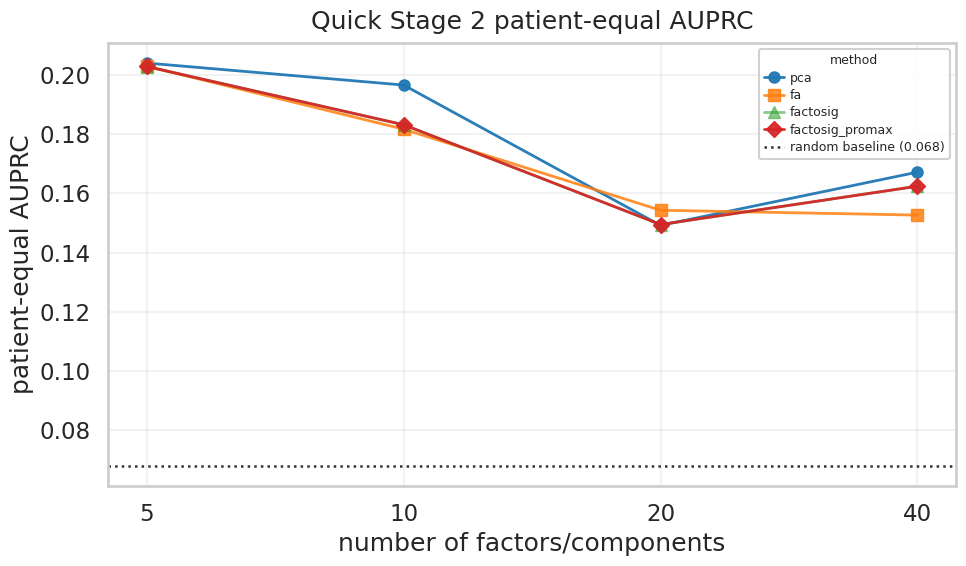

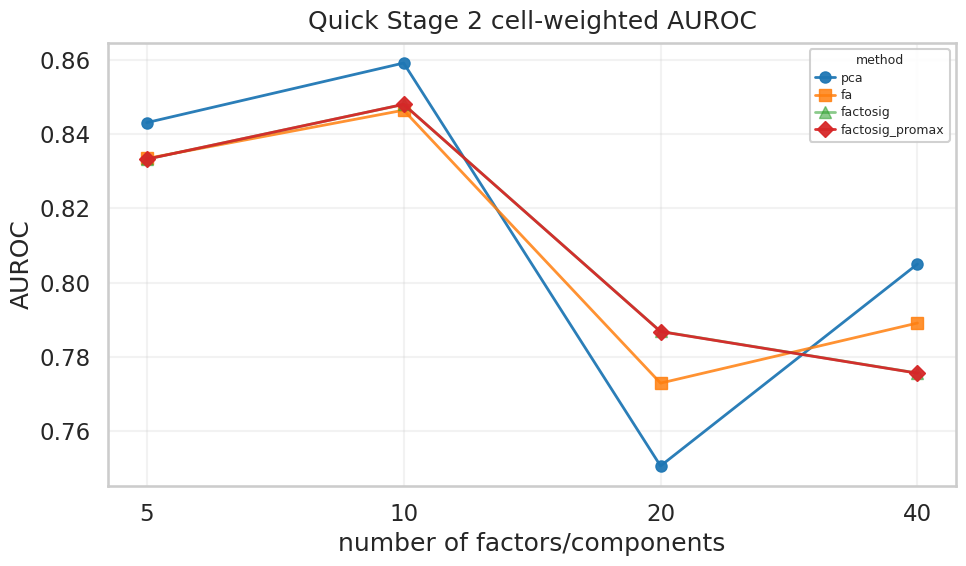

In [16]:
METHOD_ORDER = ["pca", "fa", "factosig", "factosig_promax"]
METHOD_MARKERS = {"pca": "o", "fa": "s", "factosig": "^", "factosig_promax": "D"}
METHOD_PALETTE = sns.color_palette("tab10", n_colors=len(METHOD_ORDER))
METHOD_COLORS = dict(zip(METHOD_ORDER, METHOD_PALETTE))
METHOD_ALPHA = {"pca": 0.95, "fa": 0.85, "factosig": 0.55, "factosig_promax": 0.95}
K_ORDER = [5, 10, 20, 40]


def style_quick_axis(ax: plt.Axes) -> None:
    ax.set_xscale("log", base=2)
    ax.set_xticks(K_ORDER)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel("number of factors/components")
    ax.grid(True, alpha=0.25)


def compact_legend(ax: plt.Axes, title: str | None = None) -> None:
    ax.legend(
        title=title,
        loc="upper right",
        fontsize=9,
        title_fontsize=9,
        frameon=True,
        framealpha=0.9,
        borderpad=0.4,
        labelspacing=0.35,
        handlelength=1.6,
        handletextpad=0.5,
    )


baseline_pred_path = next(STAGE2_ROOT.glob("representation=dr/method=*/k=*/seed=42/quick_l2_groupkfold_predictions.csv"))
baseline_pred = pd.read_csv(baseline_pred_path)
baseline_eval = baseline_pred[baseline_pred["included_in_metric"].astype(bool)].copy()
patient_baseline = (
    baseline_eval.groupby("patient", observed=True)["y_true"]
    .agg(n="size", n_pos="sum", malignant_fraction="mean")
    .reset_index()
)
metric_valid_patient_baseline = patient_baseline[
    patient_baseline["n_pos"].gt(0) & patient_baseline["n_pos"].lt(patient_baseline["n"])
].copy()
patient_equal_random_auprc = metric_valid_patient_baseline["malignant_fraction"].mean()
cohort_random_auprc = baseline_eval["y_true"].mean()

fig_auprc, ax_auprc = plt.subplots(figsize=(10, 6))
for method in METHOD_ORDER:
    method_df = quick_metrics[quick_metrics["method"].eq(method)].sort_values("k")
    ax_auprc.plot(
        method_df["k"],
        method_df["patient_equal_auprc"],
        color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method],
        linewidth=2.0,
        markersize=8,
        alpha=METHOD_ALPHA[method],
        label=method,
    )

ax_auprc.axhline(
    patient_equal_random_auprc,
    color="black",
    linestyle=":",
    linewidth=1.8,
    alpha=0.8,
    label=f"random baseline ({patient_equal_random_auprc:.3f})",
)

style_quick_axis(ax_auprc)
ax_auprc.set_title("Quick Stage 2 patient-equal AUPRC", pad=10)
ax_auprc.set_ylabel("patient-equal AUPRC")
compact_legend(ax_auprc, title="method")
fig_auprc.tight_layout()

fig_auroc, ax_auroc = plt.subplots(figsize=(10, 6))
for method in METHOD_ORDER:
    method_df = quick_metrics[quick_metrics["method"].eq(method)].sort_values("k")
    ax_auroc.plot(
        method_df["k"],
        method_df["quick_cell_weighted_auroc"],
        color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method],
        linewidth=2.0,
        markersize=8,
        alpha=METHOD_ALPHA[method],
        label=method,
    )

style_quick_axis(ax_auroc)
ax_auroc.set_title("Quick Stage 2 cell-weighted AUROC", pad=10)
ax_auroc.set_ylabel("AUROC")
compact_legend(ax_auroc, title="method")
fig_auroc.tight_layout()

best_patient_equal = quick_metrics.sort_values("patient_equal_auprc", ascending=False).iloc[0]
best_cell_weighted_auroc = quick_metrics.sort_values("quick_cell_weighted_auroc", ascending=False).iloc[0]

print("Patient-equal random AUPRC baseline:", f"{patient_equal_random_auprc:.3f}")
print("Cohort-wide random AUPRC baseline, not plotted:", f"{cohort_random_auprc:.3f}")
print("Best quick patient-equal AUPRC:", f"{best_patient_equal.method}/k={int(best_patient_equal.k)}", f"= {best_patient_equal.patient_equal_auprc:.3f}")
print("Best quick cell-weighted AUROC:", f"{best_cell_weighted_auroc.method}/k={int(best_cell_weighted_auroc.k)}", f"= {best_cell_weighted_auroc.quick_cell_weighted_auroc:.3f}")
print(f"Deep-dive representation: method={SELECTED_METHOD}, k={SELECTED_K}")
print("factosig_promax is included; at several k values it overlaps factosig almost exactly on these metrics.")

## 2. Deep Dive Representation

The quick screen above compares all 16 Stage 1 representations. Everything below this section uses one chosen representation, controlled by `SELECTED_METHOD` and `SELECTED_K` in the setup cell.

Default: `factosig_promax/k=40`.

**Why not the quick-screen winner (PCA/k=5)?** The quick screen optimizes classification metrics. The deep dive optimizes biological interpretability: can we name what each latent axis means?

**What "deep dive" means here**

1. Load Stage 1 factor scores (`scores.npy`) and top-loading genes for the chosen representation.
2. Run strict leave-one-patient-out (LOPO) logistic regression with progressively stricter controls.
3. Compare malignant vs normal factor usage per patient (Cliff's delta).
4. Label factors by top-loading genes (primitive HSC, quiescence, inflammatory/niche, etc.).

**Why `factosig_promax` is more interpretable than PCA**

- PCA components are orthogonal mathematical directions; loadings can be diffuse and harder to name biologically.
- FactoSig applies a rotated factor model (promax) so each factor tends to load on a tighter gene set with clearer biological themes (e.g. PROM1/HLF/MEIS1 on one factor, AREG/inflammatory genes on another).
- Higher `k=40` gives more axes to separate primitive identity, quiescence, and niche/inflammatory programs rather than collapsing them into one "stemness" direction.

For a performance-first rerun, set `SELECTED_METHOD = "pca"` and `SELECTED_K = 5` in the setup cell.

In [4]:
def representation_dir(method: str, k: int) -> Path:
    return STAGE1_ROOT / f"method={method}" / f"k={k}" / f"seed={SEED}"


def stage2_representation_dir(method: str, k: int) -> Path:
    return STAGE2_ROOT / "representation=dr" / f"method={method}" / f"k={k}" / f"seed={SEED}"


REP_DIR = representation_dir(SELECTED_METHOD, SELECTED_K)
STAGE2_REP_DIR = stage2_representation_dir(SELECTED_METHOD, SELECTED_K)

scores = np.load(REP_DIR / "scores.npy")
feature_names = [f"factor_{idx + 1:03d}" for idx in range(scores.shape[1])]
scores_df = pd.DataFrame(scores, columns=feature_names)

quick_pred = pd.read_csv(STAGE2_REP_DIR / "quick_l2_groupkfold_predictions.csv")
if scores.shape[0] != quick_pred.shape[0]:
    raise ValueError(f"scores rows ({scores.shape[0]}) do not match prediction rows ({quick_pred.shape[0]})")

obs_cols = [
    "patient",
    "CN.label",
    "Tech",
    "timepoint_type",
    "Time",
    "source",
    "predicted.annotation",
    "predicted.annotation.score",
    "Days from SCT",
    "Days.from.Relapse",
]
adata = ad.read_h5ad(INPUT_H5AD, backed="r")
obs = adata.obs[obs_cols].loc[quick_pred["barcode"].astype(str)].reset_index().rename(columns={"index": "barcode"})
if not np.array_equal(obs["barcode"].astype(str).to_numpy(), quick_pred["barcode"].astype(str).to_numpy()):
    raise ValueError("AnnData obs order does not match Stage 2 prediction order")

meta = pd.concat(
    [quick_pred[["barcode", "patient", "CN.label", "y_true", "included_in_metric"]], obs.drop(columns=["barcode", "patient", "CN.label"])],
    axis=1,
)
meta["cell_state_control"] = np.select(
    [
        meta["predicted.annotation"].isin(HSC_MPP_ANNOTATIONS),
        meta["predicted.annotation"].isin(HSC_MPP_LMPP_ANNOTATIONS),
    ],
    ["HSC/MPP", "HSC/MPP/LMPP"],
    default="other",
)

print(f"Loaded {scores.shape[0]:,} cells x {scores.shape[1]} factors for {SELECTED_METHOD}/k={SELECTED_K}")
print(pd.crosstab(meta["patient"], meta["CN.label"]).to_string())
print("\nCell-state labels:")
print(meta["predicted.annotation"].value_counts().to_string())

Loaded 60,118 cells x 5 factors for pca/k=5
CN.label  cancer  normal
patient                 
P01           45   11815
P02          211    1251
P03          758    1569
P04          102    1026
P05            8    4351
P06           44    3215
P07           22    2163
P08            0    1411
P09          375   16751
P10            0    2715
P11            0    4024
P12            0    2488
P13            4    5770

Cell-state labels:
predicted.annotation
CLP         12181
MEP-EP      10533
HSC/MPP2     6627
cDC          5403
NP2          4690
NP1          4649
pDC2         4612
LMPP         3212
pDC1         3071
HSC/MPP1     1832
EBM          1366
ncMono       1073
MEP-MkP       869


,CN.label,predicted.annotation,n,fraction_within_label
3,cancer,HSC/MPP2,643,0.409815
7,cancer,NP1,286,0.182282
4,cancer,LMPP,176,0.112173
2,cancer,HSC/MPP1,175,0.111536
9,cancer,cDC,82,0.052263
6,cancer,MEP-MkP,77,0.049076
8,cancer,NP2,44,0.028043
5,cancer,MEP-EP,21,0.013384
1,cancer,EBM,20,0.012747
11,cancer,pDC1,20,0.012747


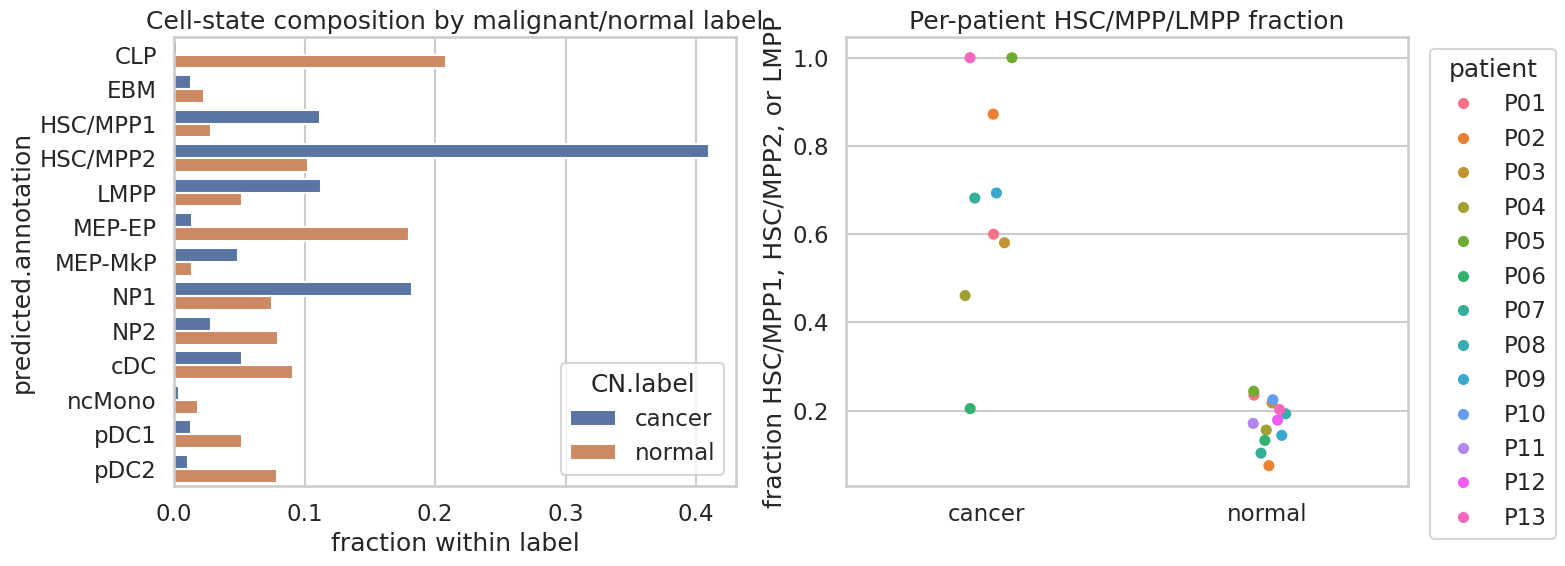

In [5]:
composition = (
    meta.groupby(["CN.label", "predicted.annotation"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
composition["fraction_within_label"] = composition["n"] / composition.groupby("CN.label")["n"].transform("sum")

patient_composition = (
    meta.assign(hsc_mpp_lmpp=meta["predicted.annotation"].isin(HSC_MPP_LMPP_ANNOTATIONS))
    .groupby(["patient", "CN.label"], observed=True)["hsc_mpp_lmpp"]
    .mean()
    .reset_index(name="fraction_hsc_mpp_lmpp")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=composition, x="fraction_within_label", y="predicted.annotation", hue="CN.label", ax=axes[0])
axes[0].set_title("Cell-state composition by malignant/normal label")
axes[0].set_xlabel("fraction within label")
axes[0].set_ylabel("predicted.annotation")

sns.stripplot(data=patient_composition, x="CN.label", y="fraction_hsc_mpp_lmpp", hue="patient", dodge=False, size=8, ax=axes[1])
axes[1].set_title("Per-patient HSC/MPP/LMPP fraction")
axes[1].set_xlabel("")
axes[1].set_ylabel("fraction HSC/MPP1, HSC/MPP2, or LMPP")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="patient")
plt.tight_layout()

composition.sort_values(["CN.label", "fraction_within_label"], ascending=[True, False]).head(20)

## 3. Strict LOPO Controls

All analyses below use the deep-dive representation (`SELECTED_METHOD` / `SELECTED_K`, default `pca/k=5`).

Each bar in the per-patient plot is one held-out patient. Five progressively stricter LOPO logistic-regression models:

| `analysis` label | What it uses |
|---|---|
| `annotation_only_all_cells` | Only `predicted.annotation` (one-hot). Baseline: can cell-type composition alone separate malignant from normal? |
| `factors_all_cells` | All Jaatinen factor scores. Main test: does the HSC-up decomposition classify malignant MRD across patients? |
| `factors_annotation_residualized_all_cells` | Factor scores minus within-annotation mean (and scaled). Tests malignant signal beyond broad cell-state identity. |
| `factors_HSC_MPP_only` | Same factors, but only HSC/MPP1 and HSC/MPP2 cells. Within-primitive-space comparison. |
| `factors_HSC_MPP_LMPP_only` | Same factors, but HSC/MPP1, HSC/MPP2, and LMPP cells. Slightly broader HSC-like gate. |

AUPRC is prevalence-sensitive, so patient-equal mean AUPRC is the main recurrence metric. Patients with only normal cells in the filtered MRD/CITE set are retained in prediction but excluded from AUROC/AUPRC means.

In [6]:
def make_numeric_l2_pipeline(seed: int = SEED) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
            ("scaler", StandardScaler()),
            # Fast for many cells and tens of factors; keeps L2 logistic + class balancing.
            ("clf", LogisticRegression(solver="newton-cholesky", class_weight="balanced", max_iter=200, random_state=seed)),
        ]
    )


def make_annotation_l2_pipeline(seed: int = SEED) -> Pipeline:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return Pipeline(
        [
            ("encode", encoder),
            ("clf", LogisticRegression(solver="newton-cholesky", class_weight="balanced", max_iter=200, random_state=seed)),
        ]
    )


def coefficient_from_numeric_pipeline(pipe: Pipeline) -> np.ndarray:
    clf = pipe.named_steps["clf"]
    scaler = pipe.named_steps["scaler"]
    return clf.coef_[0] / scaler.scale_


def strict_lopo_numeric(
    X: np.ndarray,
    meta_df: pd.DataFrame,
    feature_names: list[str],
    analysis: str,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    y = meta_df["y_true"].to_numpy(dtype=int)
    groups = meta_df["patient"].astype(str).to_numpy()
    predictions = np.full(len(y), np.nan)
    metric_rows = []
    coef_rows = []

    for train_idx, test_idx in LeaveOneGroupOut().split(X, y, groups):
        heldout_patient = str(groups[test_idx][0])
        if len(np.unique(y[train_idx])) < 2:
            continue
        pipe = make_numeric_l2_pipeline()
        pipe.fit(X[train_idx], y[train_idx])
        predictions[test_idx] = pipe.predict_proba(X[test_idx])[:, 1]
        coef = coefficient_from_numeric_pipeline(pipe)
        coef_rows.append(
            pd.DataFrame(
                {
                    "analysis": analysis,
                    "heldout_patient": heldout_patient,
                    "feature": feature_names,
                    "coef": coef,
                }
            )
        )
        metric_rows.append(
            {
                "analysis": analysis,
                "heldout_patient": heldout_patient,
                **safe_binary_metrics(y[test_idx], predictions[test_idx]),
            }
        )

    pred_df = meta_df[["barcode", "patient", "CN.label", "y_true", "predicted.annotation"]].copy()
    pred_df["analysis"] = analysis
    pred_df["y_prob"] = predictions
    return pd.DataFrame(metric_rows), pd.concat(coef_rows, ignore_index=True), pred_df


def strict_lopo_annotation_only(meta_df: pd.DataFrame, analysis: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = meta_df[["predicted.annotation"]].astype(str)
    y = meta_df["y_true"].to_numpy(dtype=int)
    groups = meta_df["patient"].astype(str).to_numpy()
    predictions = np.full(len(y), np.nan)
    metric_rows = []

    for train_idx, test_idx in LeaveOneGroupOut().split(X, y, groups):
        heldout_patient = str(groups[test_idx][0])
        if len(np.unique(y[train_idx])) < 2:
            continue
        pipe = make_annotation_l2_pipeline()
        pipe.fit(X.iloc[train_idx], y[train_idx])
        predictions[test_idx] = pipe.predict_proba(X.iloc[test_idx])[:, 1]
        metric_rows.append(
            {
                "analysis": analysis,
                "heldout_patient": heldout_patient,
                **safe_binary_metrics(y[test_idx], predictions[test_idx]),
            }
        )

    pred_df = meta_df[["barcode", "patient", "CN.label", "y_true", "predicted.annotation"]].copy()
    pred_df["analysis"] = analysis
    pred_df["y_prob"] = predictions
    return pd.DataFrame(metric_rows), pred_df


def within_annotation_zscore(values: pd.DataFrame, annotation: pd.Series) -> pd.DataFrame:
    centered = values.copy()
    for label, idx in annotation.astype(str).groupby(annotation.astype(str)).groups.items():
        block = values.loc[idx]
        sd = block.std(axis=0, ddof=0).replace(0, 1.0)
        centered.loc[idx] = (block - block.mean(axis=0)) / sd
    return centered


def summarize_lopo_metrics(metrics_df: pd.DataFrame) -> pd.DataFrame:
    valid = metrics_df[metrics_df["n_pos"].gt(0) & metrics_df["n_neg"].gt(0)].copy()
    return (
        valid.groupby("analysis", observed=True)
        .agg(
            n_metric_valid_patients=("heldout_patient", "nunique"),
            patient_equal_auroc=("auroc", "mean"),
            patient_equal_auprc=("auprc", "mean"),
            median_patient_auprc=("auprc", "median"),
            min_patient_auprc=("auprc", "min"),
            max_patient_auprc=("auprc", "max"),
        )
        .reset_index()
        .sort_values("patient_equal_auprc", ascending=False)
    )

In [7]:
lopo_metrics_parts: list[pd.DataFrame] = []
lopo_coef_parts: list[pd.DataFrame] = []
lopo_pred_parts: list[pd.DataFrame] = []

annotation_metrics, annotation_pred = strict_lopo_annotation_only(meta, "annotation_only_all_cells")
lopo_metrics_parts.append(annotation_metrics)
lopo_pred_parts.append(annotation_pred)

all_metrics, all_coefs, all_pred = strict_lopo_numeric(scores, meta, feature_names, "factors_all_cells")
lopo_metrics_parts.append(all_metrics)
lopo_coef_parts.append(all_coefs)
lopo_pred_parts.append(all_pred)

resid_scores_df = within_annotation_zscore(scores_df, meta["predicted.annotation"])
resid_metrics, resid_coefs, resid_pred = strict_lopo_numeric(
    resid_scores_df.to_numpy(),
    meta,
    feature_names,
    "factors_annotation_residualized_all_cells",
)
lopo_metrics_parts.append(resid_metrics)
lopo_coef_parts.append(resid_coefs)
lopo_pred_parts.append(resid_pred)

for analysis, allowed_labels in [
    ("factors_HSC_MPP_only", HSC_MPP_ANNOTATIONS),
    ("factors_HSC_MPP_LMPP_only", HSC_MPP_LMPP_ANNOTATIONS),
]:
    mask = meta["predicted.annotation"].isin(allowed_labels).to_numpy()
    metrics_part, coef_part, pred_part = strict_lopo_numeric(
        scores[mask],
        meta.loc[mask].reset_index(drop=True),
        feature_names,
        analysis,
    )
    lopo_metrics_parts.append(metrics_part)
    lopo_coef_parts.append(coef_part)
    lopo_pred_parts.append(pred_part)

lopo_metrics = pd.concat(lopo_metrics_parts, ignore_index=True)
lopo_predictions = pd.concat(lopo_pred_parts, ignore_index=True)
lopo_coefs = pd.concat(lopo_coef_parts, ignore_index=True)
lopo_summary = summarize_lopo_metrics(lopo_metrics)

lopo_summary

,analysis,n_metric_valid_patients,patient_equal_auroc,patient_equal_auprc,median_patient_auprc,min_patient_auprc,max_patient_auprc
2,factors_HSC_MPP_only,9,0.687069,0.282901,0.338799,0.024411,0.633830
1,factors_HSC_MPP_LMPP_only,9,0.672173,0.216200,0.063130,0.014182,0.595036
3,factors_all_cells,9,0.846318,0.202665,0.036959,0.015260,0.662849
0,annotation_only_all_cells,9,0.775253,0.152997,0.047883,0.002206,0.527584
4,factors_annotation_residualized_all_cells,9,0.610321,0.085515,0.051055,0.009570,0.333048


,analysis,heldout_patient,n,n_pos,n_neg,auroc,auprc,balanced_accuracy,f1
0,annotation_only_all_cells,P01,11860,45,11815,0.743858,0.009345,0.662825,0.015656
1,annotation_only_all_cells,P02,1462,211,1251,0.919232,0.527584,0.889143,0.696296
2,annotation_only_all_cells,P03,2327,758,1569,0.698873,0.504845,0.662792,0.558569
3,annotation_only_all_cells,P04,1128,102,1026,0.738404,0.195960,0.689428,0.307317
4,annotation_only_all_cells,P05,4359,8,4351,0.760256,0.005001,0.841990,0.011503
5,annotation_only_all_cells,P06,3259,44,3215,0.591227,0.017322,0.516280,0.029412
6,annotation_only_all_cells,P07,2185,22,2163,0.872788,0.047883,0.866316,0.080306
8,annotation_only_all_cells,P09,17126,375,16751,0.826556,0.066827,0.766634,0.125354
12,annotation_only_all_cells,P13,5774,4,5770,0.826083,0.002206,0.855286,0.004768
52,factors_HSC_MPP_LMPP_only,P01,2805,27,2778,0.768299,0.028845,0.715843,0.035088


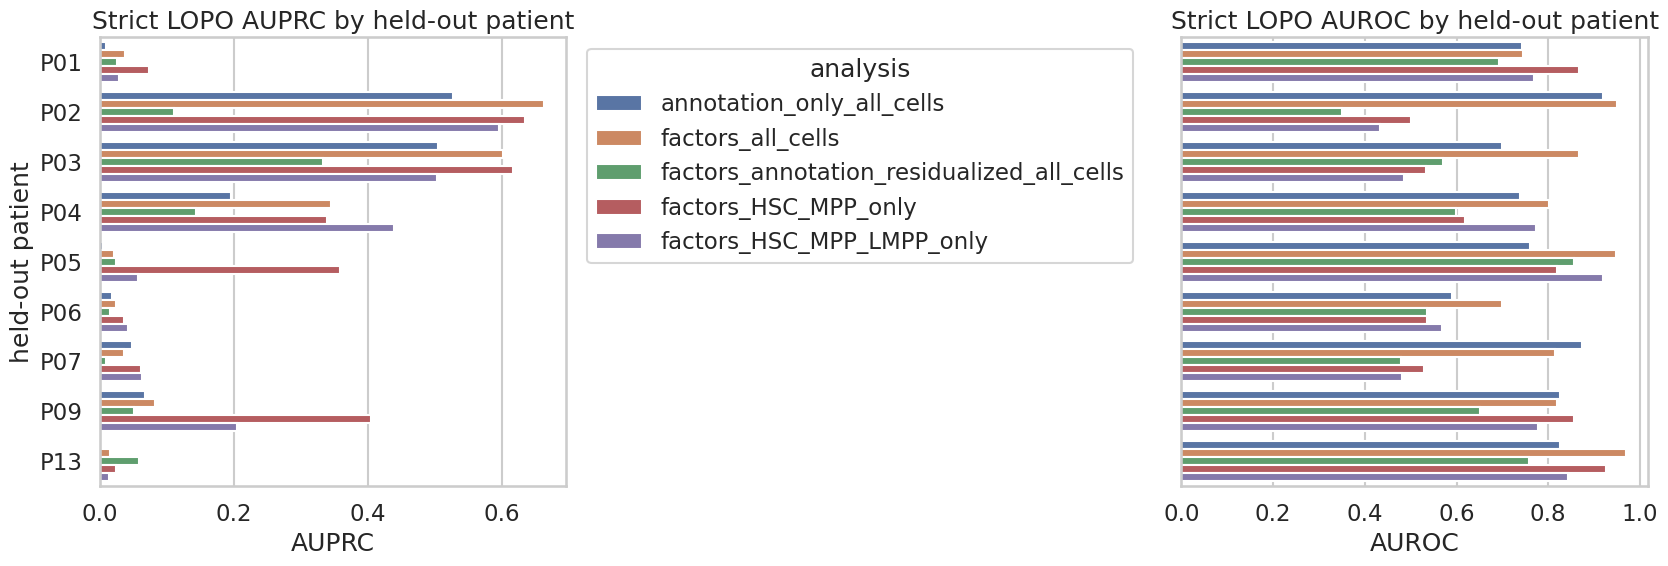

In [8]:
valid_lopo = lopo_metrics[lopo_metrics["n_pos"].gt(0) & lopo_metrics["n_neg"].gt(0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)
sns.barplot(data=valid_lopo, x="auprc", y="heldout_patient", hue="analysis", ax=axes[0])
axes[0].set_title("Strict LOPO AUPRC by held-out patient")
axes[0].set_xlabel("AUPRC")
axes[0].set_ylabel("held-out patient")

sns.barplot(data=valid_lopo, x="auroc", y="heldout_patient", hue="analysis", ax=axes[1])
axes[1].set_title("Strict LOPO AUROC by held-out patient")
axes[1].set_xlabel("AUROC")
axes[1].set_ylabel("")
axes[1].legend_.remove()
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="analysis")
plt.tight_layout()

valid_lopo.sort_values(["analysis", "heldout_patient"])[
    ["analysis", "heldout_patient", "n", "n_pos", "n_neg", "auroc", "auprc", "balanced_accuracy", "f1"]
]

,heldout_patient,TP,FP,TN,FN,n,n_pos
0,P01,31,5062,6753,14,11860,45
1,P02,172,92,1159,39,1462,211
2,P03,699,380,1189,59,2327,758
3,P04,72,250,776,30,1128,102
4,P05,8,1184,3167,0,4359,8
5,P06,12,578,2637,32,3259,44
6,P07,11,282,1881,11,2185,22
7,P09,230,2529,14222,145,17126,375
8,P13,4,928,4842,0,5774,4


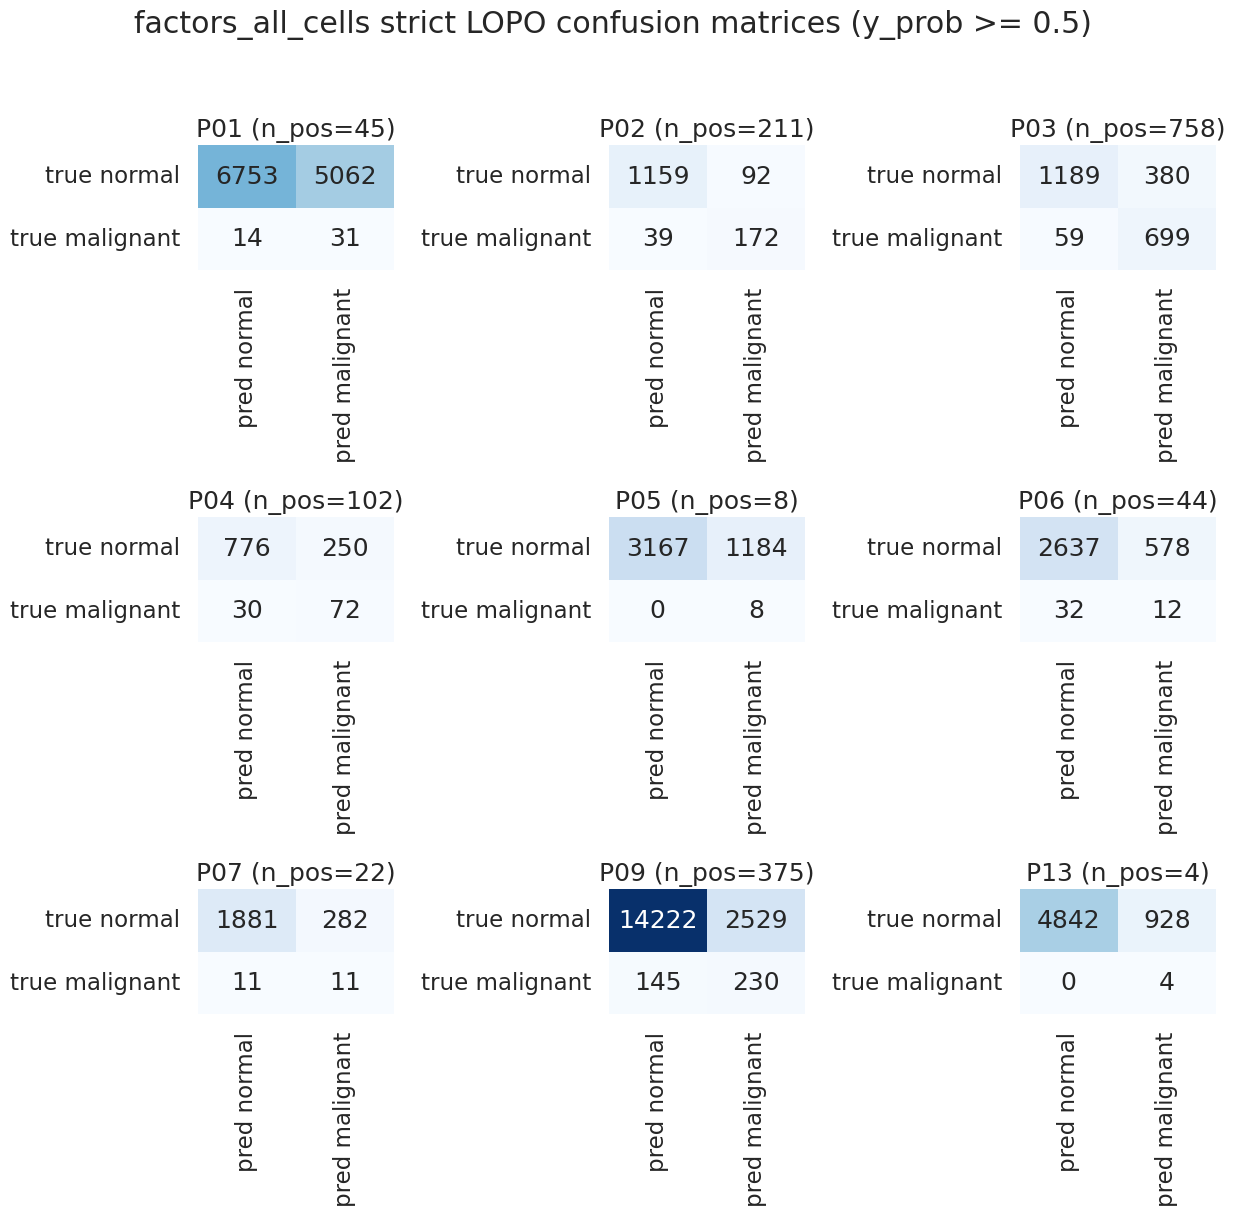

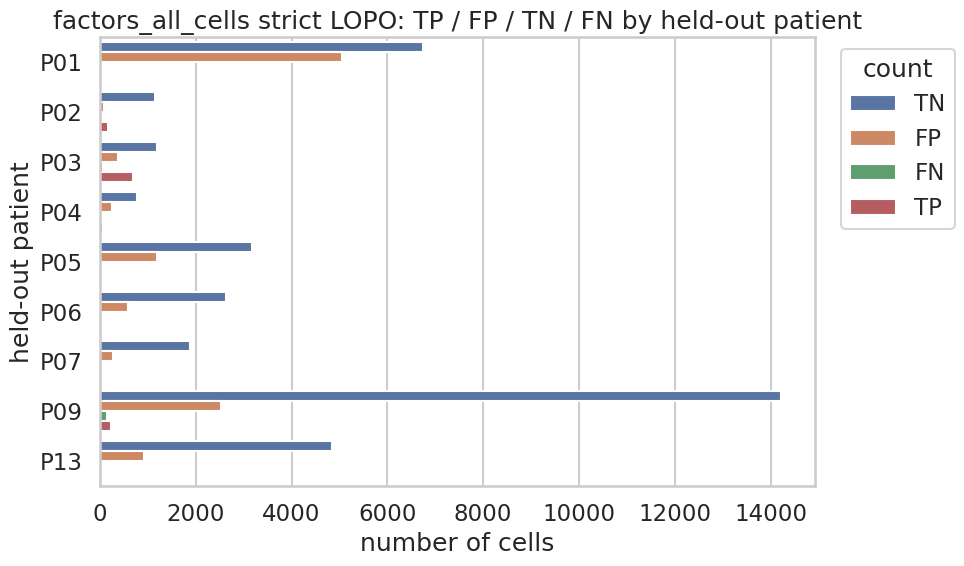

In [9]:
# Confusion-matrix counts for factors_all_cells strict LOPO (threshold = 0.5).
fac_all_pred = lopo_predictions[lopo_predictions["analysis"].eq("factors_all_cells")].copy()
fac_all_pred["y_pred"] = (fac_all_pred["y_prob"] >= 0.5).astype(int)

cm_rows = []
for patient, group in fac_all_pred.groupby("patient", sort=True):
    y_true = group["y_true"].to_numpy(dtype=int)
    y_pred = group["y_pred"].to_numpy(dtype=int)
    if len(np.unique(y_true)) < 2:
        continue
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    cm_rows.append({"heldout_patient": patient, "TP": tp, "FP": fp, "TN": tn, "FN": fn, "n": len(group), "n_pos": int(y_true.sum())})

cm_fac_all = pd.DataFrame(cm_rows).sort_values("heldout_patient")

patient_order = cm_fac_all["heldout_patient"].tolist()
n_patients = len(patient_order)
ncols = 3
nrows = int(np.ceil(n_patients / ncols))

fig_cm, axes_cm = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), squeeze=False)
cm_vmax = max(cm_fac_all[["TP", "FP", "TN", "FN"]].to_numpy().max(), 1)

for idx, patient in enumerate(patient_order):
    ax = axes_cm[idx // ncols, idx % ncols]
    row = cm_fac_all.loc[cm_fac_all["heldout_patient"].eq(patient)].iloc[0]
    matrix = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]], dtype=float)
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        vmin=0,
        vmax=cm_vmax,
        cbar=False,
        xticklabels=["pred normal", "pred malignant"],
        yticklabels=["true normal", "true malignant"],
        ax=ax,
    )
    ax.set_title(f"{patient} (n_pos={int(row['n_pos'])})")
    ax.set_xlabel("")
    ax.set_ylabel("")

for idx in range(n_patients, nrows * ncols):
    axes_cm[idx // ncols, idx % ncols].axis("off")

fig_cm.suptitle("factors_all_cells strict LOPO confusion matrices (y_prob >= 0.5)", y=1.02)
fig_cm.tight_layout()

fig_counts, ax_counts = plt.subplots(figsize=(10, 6))
cm_long = cm_fac_all.melt(
    id_vars=["heldout_patient", "n_pos"],
    value_vars=["TP", "FP", "TN", "FN"],
    var_name="count_type",
    value_name="n_cells",
)
sns.barplot(
    data=cm_long,
    x="n_cells",
    y="heldout_patient",
    hue="count_type",
    order=patient_order,
    hue_order=["TN", "FP", "FN", "TP"],
    ax=ax_counts,
)
ax_counts.set_title("factors_all_cells strict LOPO: TP / FP / TN / FN by held-out patient")
ax_counts.set_xlabel("number of cells")
ax_counts.set_ylabel("held-out patient")
ax_counts.legend(title="count", bbox_to_anchor=(1.02, 1), loc="upper left")
fig_counts.tight_layout()

cm_fac_all

,analysis,feature,n_models,median_coef,median_abs_coef,frac_positive,frac_negative,dominant_sign_fraction,dominant_sign
3,factors_HSC_MPP_LMPP_only,factor_004,13,-0.198801,0.198801,0.000000,1.000000,1.000000,-
4,factors_HSC_MPP_LMPP_only,factor_005,13,-0.160317,0.160317,0.000000,1.000000,1.000000,-
0,factors_HSC_MPP_LMPP_only,factor_001,13,-0.082793,0.082793,0.000000,1.000000,1.000000,-
2,factors_HSC_MPP_LMPP_only,factor_003,13,-0.226059,0.226059,0.076923,0.923077,0.923077,-
1,factors_HSC_MPP_LMPP_only,factor_002,13,0.006209,0.009418,0.769231,0.230769,0.769231,+
5,factors_HSC_MPP_only,factor_001,13,-0.378995,0.378995,0.000000,1.000000,1.000000,-
6,factors_HSC_MPP_only,factor_002,13,0.297929,0.297929,1.000000,0.000000,1.000000,+
8,factors_HSC_MPP_only,factor_004,13,-0.288616,0.288616,0.000000,1.000000,1.000000,-
9,factors_HSC_MPP_only,factor_005,13,-0.213424,0.213424,0.000000,1.000000,1.000000,-
7,factors_HSC_MPP_only,factor_003,13,0.012082,0.015084,0.615385,0.384615,0.615385,+


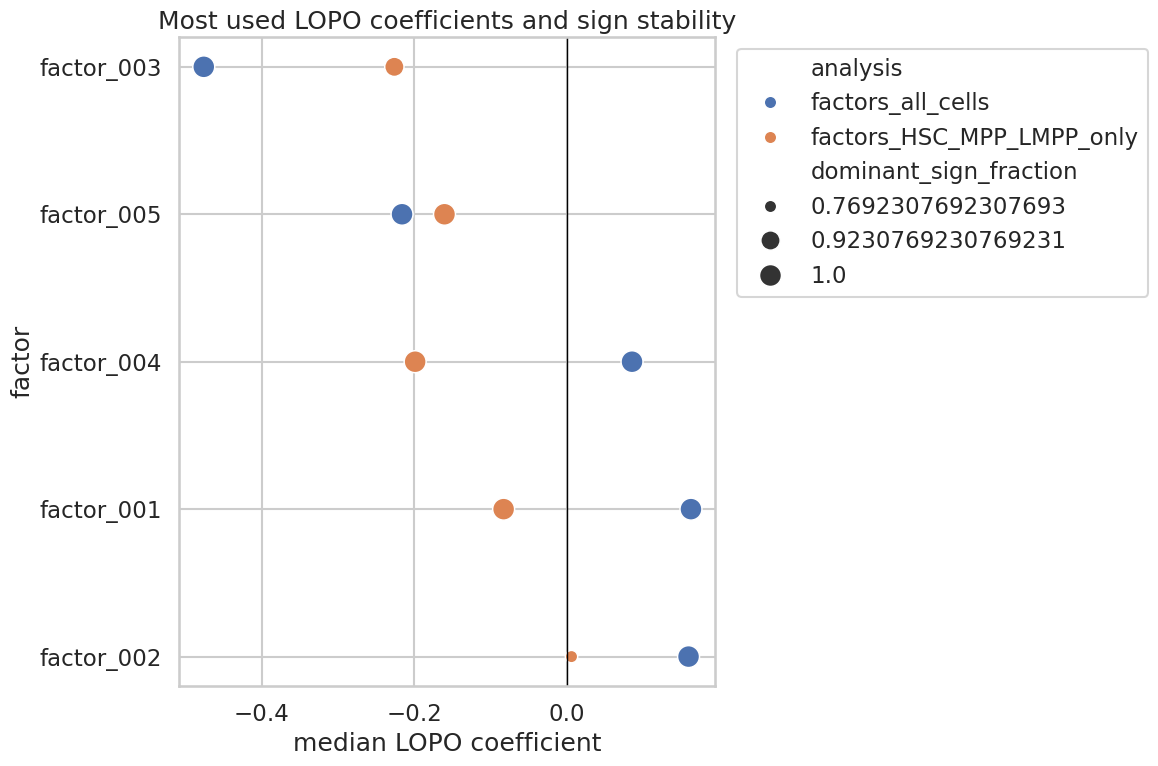

In [10]:
def summarize_coefficient_stability(coefs: pd.DataFrame, min_abs_median_coef: float = 0.0) -> pd.DataFrame:
    out = (
        coefs.assign(sign=lambda d: np.sign(d["coef"]))
        .groupby(["analysis", "feature"], observed=True)
        .agg(
            n_models=("heldout_patient", "nunique"),
            median_coef=("coef", "median"),
            median_abs_coef=("coef", lambda x: float(np.median(np.abs(x)))),
            frac_positive=("coef", lambda x: float((x > 0).mean())),
            frac_negative=("coef", lambda x: float((x < 0).mean())),
        )
        .reset_index()
    )
    out["dominant_sign_fraction"] = out[["frac_positive", "frac_negative"]].max(axis=1)
    out["dominant_sign"] = np.where(out["frac_positive"] >= out["frac_negative"], "+", "-")
    out = out[out["median_abs_coef"].ge(min_abs_median_coef)].copy()
    return out.sort_values(["analysis", "dominant_sign_fraction", "median_abs_coef"], ascending=[True, False, False])

coef_stability = summarize_coefficient_stability(lopo_coefs)

plot_coef = (
    coef_stability[coef_stability["analysis"].isin(["factors_all_cells", "factors_HSC_MPP_LMPP_only"])]
    .sort_values("median_abs_coef", ascending=False)
    .groupby("analysis", observed=True)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=plot_coef,
    x="median_coef",
    y="feature",
    hue="analysis",
    size="dominant_sign_fraction",
    sizes=(80, 250),
    ax=ax,
)
ax.axvline(0, color="black", lw=1)
ax.set_title("Most used LOPO coefficients and sign stability")
ax.set_xlabel("median LOPO coefficient")
ax.set_ylabel("factor")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

coef_stability.head(30)

## 4. Factor Interpretation From Top Loadings

This is not a replacement for manual biology review. It is a first-pass labeler that asks whether each factor's top-loading genes overlap expected axes:

- primitive HSC/CD133-like identity
- quiescence/growth suppression
- inflammatory/niche interaction
- IFN/TNF/TGF response
- CD54/CD244 or immune-visibility markers

In [11]:
top_loading_genes = pd.read_csv(REP_DIR / "top_loading_genes.csv")

AXIS_MARKERS = {
    "primitive_hsc_cd133": {
        "PROM1", "CD34", "HLF", "MEIS1", "MECOM", "ERG", "FLT3", "SPINK2", "BAALC", "GATA2", "HOXA5", "HOXB2", "HOXB3", "MLLT3", "FGD5", "ALDH1A1", "ANGPT1", "ZNF521", "RBPMS", "NPR3"
    },
    "quiescence_growth_suppression": {
        "CDKN1A", "CDKN1B", "CDKN1C", "BTG1", "BTG2", "BTG3", "GADD45A", "GADD45B", "GADD45G", "FOXO1", "FOXO3", "KLF4", "DUSP1", "DUSP6", "TOB1", "TOB2", "TXNIP", "SESN1", "SESN2"
    },
    "inflammatory_niche": {
        "TNF", "TNFAIP3", "TNFAIP6", "NFKBIA", "NFKBIZ", "RELA", "JUN", "FOS", "CXCL8", "CXCL10", "CCL2", "CCL3", "CCL4", "IL1B", "IL1R1", "IL6", "AREG", "PTGS2", "CD44", "ITGA4", "ITGA5", "ITGA9", "VCAM1", "THBS1", "LGALS3"
    },
    "ifn_response": {
        "IFIT1", "IFIT2", "IFIT3", "ISG15", "IFI6", "IFI27", "IFI44", "IFI44L", "IRF1", "IRF7", "STAT1", "STAT2", "MX1", "MX2", "OAS1", "OAS2", "OAS3", "BST2", "ISG20"
    },
    "tgfb_niche_quiescence": {
        "TGFB1", "TGFB2", "TGFBR1", "TGFBR2", "SMAD2", "SMAD3", "SMAD4", "SERPINE1", "ID1", "ID2", "ID3", "JUNB", "KLF10", "THBS1", "THBS4", "COL4A1", "COL5A1", "FN1"
    },
    "cd54_cd244_immune_visibility": {
        "ICAM1", "CD244", "SLAMF1", "CD48", "CD58", "CD74", "HLA-DRA", "HLA-DRB1", "HLA-DRB4", "HLA-A", "HLA-B", "HLA-C", "B2M", "CIITA", "TAP1", "TAP2", "LGALS9"
    },
}


def summarize_factor_genes(top_df: pd.DataFrame, n_top: int = 25) -> pd.DataFrame:
    rows = []
    for factor, group in top_df.groupby("factor_id", sort=True):
        ordered = group.sort_values("abs_loading", ascending=False).head(n_top).copy()
        genes = ordered["gene"].astype(str).str.upper().tolist()
        signed_top = ordered.sort_values("loading", ascending=False).head(8)["gene"].tolist()
        signed_bottom = ordered.sort_values("loading", ascending=True).head(8)["gene"].tolist()
        marker_hits = {
            axis: sorted(set(genes) & markers)
            for axis, markers in AXIS_MARKERS.items()
        }
        best_axis = max(marker_hits, key=lambda axis: len(marker_hits[axis]))
        rows.append(
            {
                "feature": factor,
                "putative_axis": best_axis if marker_hits[best_axis] else "unlabeled_top_loading",
                "n_marker_hits": len(marker_hits[best_axis]),
                "marker_hits": ";".join(marker_hits[best_axis]),
                "top_positive_genes": ", ".join(signed_top),
                "top_negative_genes": ", ".join(signed_bottom),
            }
        )
    return pd.DataFrame(rows)

factor_gene_summary = summarize_factor_genes(top_loading_genes, n_top=30)
factor_gene_summary.sort_values(["n_marker_hits", "feature"], ascending=[False, True]).head(20)

,feature,putative_axis,n_marker_hits,marker_hits,top_positive_genes,top_negative_genes
0,factor_001,primitive_hsc_cd133,7,ANGPT1;MEIS1;MLLT3;NPR3;PROM1;SPINK2;ZNF521,"NKAIN2, CALN1, ANGPT1, CDK6, ZNF521, MAP7, MLL...","PPM1H, GIHCG, FAM30A, HSPD1, SMYD3, DEPTOR, SM..."
3,factor_004,primitive_hsc_cd133,7,ALDH1A1;BAALC;ERG;FLT3;GATA2;SPINK2;ZNF521,"ITM2C, FLT3, RUNX2, NEGR1, FABP5, SPINK2, STMN...","PDZD2, SLC39A8, ERG, ALDH1A1, PPM1H, SMAD1, GA..."
4,factor_005,primitive_hsc_cd133,5,CD34;FLT3;HLF;RBPMS;SPINK2,"DTL, ACACA, IPO7, UHRF1, ECPAS, STK3, SMYD3, S...","FAM30A, CRHBP, RPS15A, SPINK2, MZB1, CD34, RBP..."
1,factor_002,primitive_hsc_cd133,4,ALDH1A1;BAALC;ERG;FLT3,"PLCB1, SSBP2, MSI2, GALNT7, NRIP1, VAV3, ERG, ...","NME1, HSPD1, CDK4, GCSH, ALDH1A1, PRDX4, PSMB5..."
2,factor_003,primitive_hsc_cd133,1,ERG,"IGLL1, SOCS2, UHRF1, COL5A1, SSBP2, ERG, STMN1...","RUNX2, ADAM28, MSRB3, DST, SCN9A, PLAGL1, AREG..."


## 5. Patient-Specific Factor Usage

Uses factor scores from the deep-dive representation (`SELECTED_METHOD` / `SELECTED_K`, default **`factosig_promax/k=40`**). The `scores_df` loaded in section 2 is the input here.

For each patient and factor, compute malignant minus normal median factor usage and **Cliff's delta** (effect size for malignant > normal, manuscript-aligned with cNMF program-usage comparisons).

- **Cliff's delta > 0 (red in heatmap)**: malignant cells tend to use this factor more than donor/normal cells in that patient.
- **Cliff's delta < 0 (blue)**: normal cells use the factor more.
- **Near 0 (white)**: little malignant-vs-normal separation for that factor in that patient.

Recurrence counts patients where malignant > normal with Cliff's delta above a small threshold (`0.147`).

The default Cliff's delta thresholds are conventional: small `0.147`, medium `0.33`, large `0.474`.

In [12]:
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """Exact Cliff's delta, computed without repeated Mann-Whitney ranking overhead."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    y_sorted = np.sort(y)
    less = np.searchsorted(y_sorted, x, side="left")
    greater = len(y_sorted) - np.searchsorted(y_sorted, x, side="right")
    return float((less.sum() - greater.sum()) / (len(x) * len(y)))


def factor_usage_by_patient(
    values: pd.DataFrame,
    meta_df: pd.DataFrame,
    analysis_subset: str,
) -> pd.DataFrame:
    rows = []
    for patient, idx in meta_df.groupby("patient", sort=True).groups.items():
        idx = list(idx)
        y = meta_df.loc[idx, "y_true"].to_numpy(dtype=int)
        if y.sum() == 0 or y.sum() == len(y):
            continue
        for factor in values.columns:
            malignant = values.loc[idx, factor].to_numpy()[y == 1]
            normal = values.loc[idx, factor].to_numpy()[y == 0]
            rows.append(
                {
                    "analysis_subset": analysis_subset,
                    "patient": patient,
                    "feature": factor,
                    "malignant_median": float(np.median(malignant)),
                    "normal_median": float(np.median(normal)),
                    "delta_median": float(np.median(malignant) - np.median(normal)),
                    "cliffs_delta": cliffs_delta(malignant, normal),
                    "n_malignant": int(len(malignant)),
                    "n_normal": int(len(normal)),
                }
            )
    return pd.DataFrame(rows)

usage_all = factor_usage_by_patient(scores_df, meta, "all_cells")
mask_hsc_lmpp = meta["predicted.annotation"].isin(HSC_MPP_LMPP_ANNOTATIONS).to_numpy()
usage_hsc_lmpp = factor_usage_by_patient(
    scores_df.loc[mask_hsc_lmpp].reset_index(drop=True),
    meta.loc[mask_hsc_lmpp].reset_index(drop=True),
    "HSC_MPP_LMPP_only",
)
usage = pd.concat([usage_all, usage_hsc_lmpp], ignore_index=True)

SMALL_CLIFFS = 0.147
recurrence = (
    usage.assign(
        recurrent_positive=lambda d: d["delta_median"].gt(0) & d["cliffs_delta"].gt(SMALL_CLIFFS),
        recurrent_negative=lambda d: d["delta_median"].lt(0) & d["cliffs_delta"].lt(-SMALL_CLIFFS),
    )
    .groupby(["analysis_subset", "feature"], observed=True)
    .agg(
        n_patients_with_both_classes=("patient", "nunique"),
        n_positive_recurrent_patients=("recurrent_positive", "sum"),
        n_negative_recurrent_patients=("recurrent_negative", "sum"),
        median_delta=("delta_median", "median"),
        median_cliffs_delta=("cliffs_delta", "median"),
        max_cliffs_delta=("cliffs_delta", "max"),
        min_cliffs_delta=("cliffs_delta", "min"),
    )
    .reset_index()
    .merge(factor_gene_summary, on="feature", how="left")
    .merge(
        coef_stability[coef_stability["analysis"].eq("factors_all_cells")][
            ["feature", "dominant_sign", "dominant_sign_fraction", "median_coef", "median_abs_coef"]
        ],
        on="feature",
        how="left",
    )
    .sort_values(["analysis_subset", "n_positive_recurrent_patients", "median_cliffs_delta"], ascending=[True, False, False])
)

recurrence.head(25)

,analysis_subset,feature,n_patients_with_both_classes,n_positive_recurrent_patients,n_negative_recurrent_patients,median_delta,median_cliffs_delta,max_cliffs_delta,min_cliffs_delta,putative_axis,n_marker_hits,marker_hits,top_positive_genes,top_negative_genes,dominant_sign,dominant_sign_fraction,median_coef,median_abs_coef
1,HSC_MPP_LMPP_only,factor_002,9,6,0,2.546894,0.436312,0.520500,-0.122741,primitive_hsc_cd133,4,ALDH1A1;BAALC;ERG;FLT3,"PLCB1, SSBP2, MSI2, GALNT7, NRIP1, VAV3, ERG, ...","NME1, HSPD1, CDK4, GCSH, ALDH1A1, PRDX4, PSMB5...",+,1.0,0.159676,0.159676
0,HSC_MPP_LMPP_only,factor_001,9,4,3,-0.385254,-0.099906,0.556117,-0.551382,primitive_hsc_cd133,7,ANGPT1;MEIS1;MLLT3;NPR3;PROM1;SPINK2;ZNF521,"NKAIN2, CALN1, ANGPT1, CDK6, ZNF521, MAP7, MLL...","PPM1H, GIHCG, FAM30A, HSPD1, SMYD3, DEPTOR, SM...",+,1.0,0.162840,0.162840
4,HSC_MPP_LMPP_only,factor_005,9,1,6,-2.134230,-0.411061,0.209703,-0.781678,primitive_hsc_cd133,5,CD34;FLT3;HLF;RBPMS;SPINK2,"DTL, ACACA, IPO7, UHRF1, ECPAS, STK3, SMYD3, S...","FAM30A, CRHBP, RPS15A, SPINK2, MZB1, CD34, RBP...",-,1.0,-0.216002,0.216002
2,HSC_MPP_LMPP_only,factor_003,9,1,6,-1.720235,-0.418202,0.287500,-0.705702,primitive_hsc_cd133,1,ERG,"IGLL1, SOCS2, UHRF1, COL5A1, SSBP2, ERG, STMN1...","RUNX2, ADAM28, MSRB3, DST, SCN9A, PLAGL1, AREG...",-,1.0,-0.475955,0.475955
3,HSC_MPP_LMPP_only,factor_004,9,0,6,-1.646828,-0.453244,0.073552,-0.633836,primitive_hsc_cd133,7,ALDH1A1;BAALC;ERG;FLT3;GATA2;SPINK2;ZNF521,"ITM2C, FLT3, RUNX2, NEGR1, FABP5, SPINK2, STMN...","PDZD2, SLC39A8, ERG, ALDH1A1, PPM1H, SMAD1, GA...",+,1.0,0.085572,0.085572
5,all_cells,factor_001,9,8,1,3.917070,0.424844,0.788735,-0.235600,primitive_hsc_cd133,7,ANGPT1;MEIS1;MLLT3;NPR3;PROM1;SPINK2;ZNF521,"NKAIN2, CALN1, ANGPT1, CDK6, ZNF521, MAP7, MLL...","PPM1H, GIHCG, FAM30A, HSPD1, SMYD3, DEPTOR, SM...",+,1.0,0.162840,0.162840
6,all_cells,factor_002,9,7,0,2.606668,0.357670,0.818950,0.034299,primitive_hsc_cd133,4,ALDH1A1;BAALC;ERG;FLT3,"PLCB1, SSBP2, MSI2, GALNT7, NRIP1, VAV3, ERG, ...","NME1, HSPD1, CDK4, GCSH, ALDH1A1, PRDX4, PSMB5...",+,1.0,0.159676,0.159676
8,all_cells,factor_004,9,3,4,0.294639,0.024957,0.682264,-0.313725,primitive_hsc_cd133,7,ALDH1A1;BAALC;ERG;FLT3;GATA2;SPINK2;ZNF521,"ITM2C, FLT3, RUNX2, NEGR1, FABP5, SPINK2, STMN...","PDZD2, SLC39A8, ERG, ALDH1A1, PPM1H, SMAD1, GA...",+,1.0,0.085572,0.085572
9,all_cells,factor_005,9,0,7,-2.062315,-0.470856,0.021012,-0.927383,primitive_hsc_cd133,5,CD34;FLT3;HLF;RBPMS;SPINK2,"DTL, ACACA, IPO7, UHRF1, ECPAS, STK3, SMYD3, S...","FAM30A, CRHBP, RPS15A, SPINK2, MZB1, CD34, RBP...",-,1.0,-0.216002,0.216002
7,all_cells,factor_003,9,0,8,-2.098854,-0.515717,-0.081747,-0.826419,primitive_hsc_cd133,1,ERG,"IGLL1, SOCS2, UHRF1, COL5A1, SSBP2, ERG, STMN1...","RUNX2, ADAM28, MSRB3, DST, SCN9A, PLAGL1, AREG...",-,1.0,-0.475955,0.475955


,analysis_subset,feature,putative_axis,n_positive_recurrent_patients,n_negative_recurrent_patients,median_cliffs_delta,dominant_sign,dominant_sign_fraction,marker_hits,top_positive_genes
0,HSC_MPP_LMPP_only,factor_001,primitive_hsc_cd133,4,3,-0.099906,+,1.0,ANGPT1;MEIS1;MLLT3;NPR3;PROM1;SPINK2;ZNF521,"NKAIN2, CALN1, ANGPT1, CDK6, ZNF521, MAP7, MLL..."
5,all_cells,factor_001,primitive_hsc_cd133,8,1,0.424844,+,1.0,ANGPT1;MEIS1;MLLT3;NPR3;PROM1;SPINK2;ZNF521,"NKAIN2, CALN1, ANGPT1, CDK6, ZNF521, MAP7, MLL..."
1,HSC_MPP_LMPP_only,factor_002,primitive_hsc_cd133,6,0,0.436312,+,1.0,ALDH1A1;BAALC;ERG;FLT3,"PLCB1, SSBP2, MSI2, GALNT7, NRIP1, VAV3, ERG, ..."
6,all_cells,factor_002,primitive_hsc_cd133,7,0,0.357670,+,1.0,ALDH1A1;BAALC;ERG;FLT3,"PLCB1, SSBP2, MSI2, GALNT7, NRIP1, VAV3, ERG, ..."
2,HSC_MPP_LMPP_only,factor_003,primitive_hsc_cd133,1,6,-0.418202,-,1.0,ERG,"IGLL1, SOCS2, UHRF1, COL5A1, SSBP2, ERG, STMN1..."
7,all_cells,factor_003,primitive_hsc_cd133,0,8,-0.515717,-,1.0,ERG,"IGLL1, SOCS2, UHRF1, COL5A1, SSBP2, ERG, STMN1..."
3,HSC_MPP_LMPP_only,factor_004,primitive_hsc_cd133,0,6,-0.453244,+,1.0,ALDH1A1;BAALC;ERG;FLT3;GATA2;SPINK2;ZNF521,"ITM2C, FLT3, RUNX2, NEGR1, FABP5, SPINK2, STMN..."
8,all_cells,factor_004,primitive_hsc_cd133,3,4,0.024957,+,1.0,ALDH1A1;BAALC;ERG;FLT3;GATA2;SPINK2;ZNF521,"ITM2C, FLT3, RUNX2, NEGR1, FABP5, SPINK2, STMN..."
4,HSC_MPP_LMPP_only,factor_005,primitive_hsc_cd133,1,6,-0.411061,-,1.0,CD34;FLT3;HLF;RBPMS;SPINK2,"DTL, ACACA, IPO7, UHRF1, ECPAS, STK3, SMYD3, S..."
9,all_cells,factor_005,primitive_hsc_cd133,0,7,-0.470856,-,1.0,CD34;FLT3;HLF;RBPMS;SPINK2,"DTL, ACACA, IPO7, UHRF1, ECPAS, STK3, SMYD3, S..."


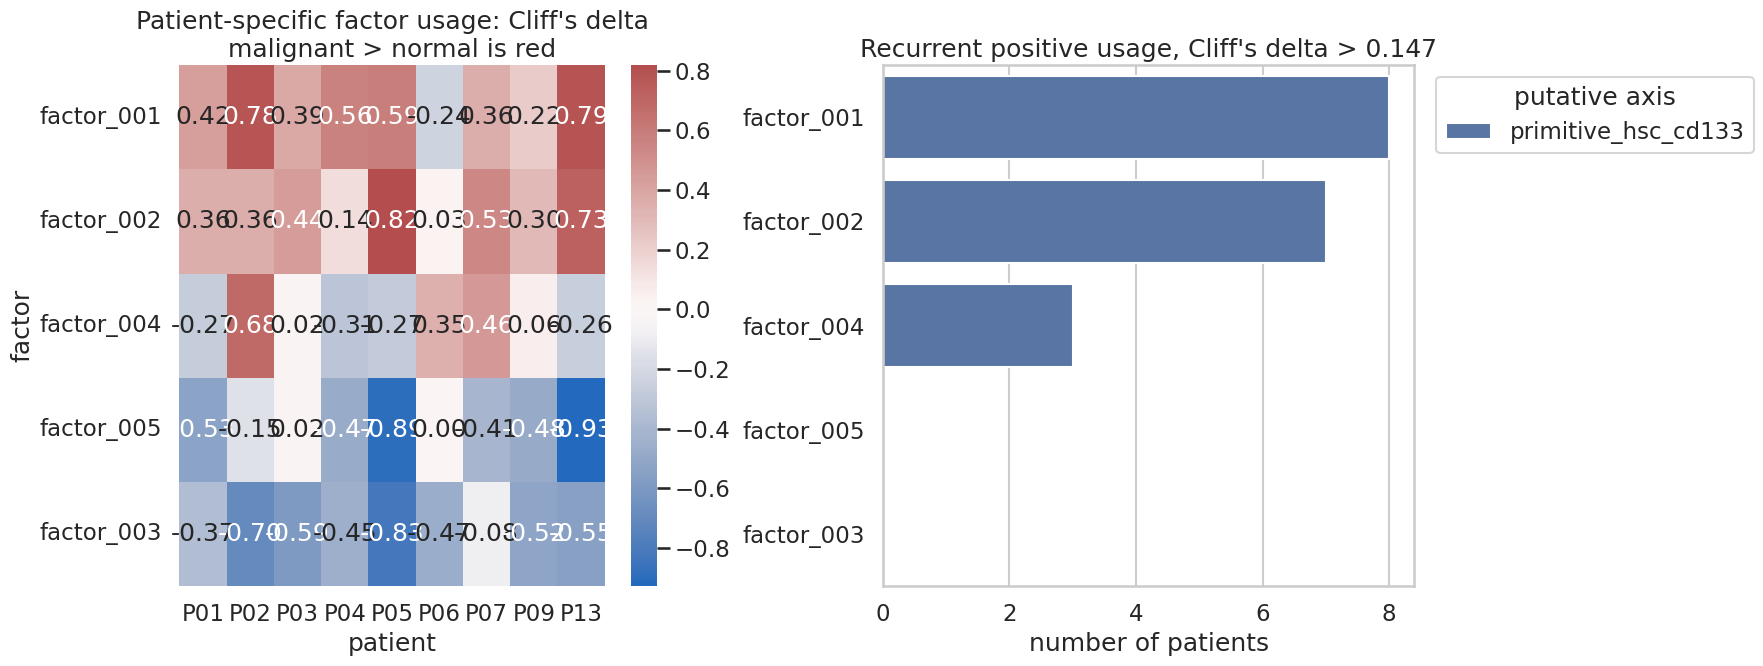

In [13]:
top_recurrent_features = (
    recurrence[recurrence["analysis_subset"].eq("all_cells")]
    .sort_values(["n_positive_recurrent_patients", "median_cliffs_delta"], ascending=False)
    .head(12)["feature"]
    .tolist()
)

usage_heatmap_df = usage[
    usage["analysis_subset"].eq("all_cells") & usage["feature"].isin(top_recurrent_features)
].copy()
usage_matrix = usage_heatmap_df.pivot(index="feature", columns="patient", values="cliffs_delta").loc[top_recurrent_features]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(usage_matrix, center=0, cmap="vlag", annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Patient-specific factor usage: Cliff's delta\nmalignant > normal is red")
axes[0].set_xlabel("patient")
axes[0].set_ylabel("factor")

plot_recur = recurrence[recurrence["feature"].isin(top_recurrent_features) & recurrence["analysis_subset"].eq("all_cells")].copy()
sns.barplot(data=plot_recur, x="n_positive_recurrent_patients", y="feature", hue="putative_axis", dodge=False, ax=axes[1])
axes[1].set_title(f"Recurrent positive usage, Cliff's delta > {SMALL_CLIFFS}")
axes[1].set_xlabel("number of patients")
axes[1].set_ylabel("")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="putative axis")
plt.tight_layout()

recurrence[recurrence["feature"].isin(top_recurrent_features)].sort_values(
    ["feature", "analysis_subset"]
)[
    [
        "analysis_subset",
        "feature",
        "putative_axis",
        "n_positive_recurrent_patients",
        "n_negative_recurrent_patients",
        "median_cliffs_delta",
        "dominant_sign",
        "dominant_sign_fraction",
        "marker_hits",
        "top_positive_genes",
    ]
]

## 6. Working Interpretation

Use this section as a first-pass decision aid rather than a final claim. Stronger manuscript claims should use the strict LOPO outputs, within-HSC/MPP controls, and recurrence table together.

In [14]:
summary = lopo_summary.set_index("analysis")

def metric_value(analysis: str, metric: str) -> float:
    return float(summary.loc[analysis, metric]) if analysis in summary.index else np.nan

interpretation_rows = [
    {
        "question": "Is existing quick Stage 2 sufficient for strict held-out-patient generalization?",
        "result": "No: it is GroupKFold by patient, not one model per held-out patient.",
        "evidence": "Use quick metrics as screen; use strict LOPO cells above for LOPO AUROC/AUPRC and coefficient stability.",
    },
    {
        "question": "Does broad cell-state composition alone classify malignant MRD?",
        "result": f"annotation-only patient-equal AUPRC = {metric_value('annotation_only_all_cells', 'patient_equal_auprc'):.3f}",
        "evidence": "If this approaches factor performance, the Jaatinen signal is partly composition-confirmatory.",
    },
    {
        "question": "Do Jaatinen factors classify across held-out patients?",
        "result": f"all-cell factor patient-equal AUPRC = {metric_value('factors_all_cells', 'patient_equal_auprc'):.3f}",
        "evidence": "This asks whether the HSC-up prior contains a shared malignant MRD axis.",
    },
    {
        "question": "Does the signal survive annotation control?",
        "result": f"annotation-residualized factor patient-equal AUPRC = {metric_value('factors_annotation_residualized_all_cells', 'patient_equal_auprc'):.3f}",
        "evidence": "Persistence after residualizing within predicted.annotation argues against pure cell-type composition.",
    },
    {
        "question": "Does the signal remain inside HSC-like space?",
        "result": f"HSC/MPP/LMPP-only patient-equal AUPRC = {metric_value('factors_HSC_MPP_LMPP_only', 'patient_equal_auprc'):.3f}",
        "evidence": "Persistence here supports malignant-specific deviation inside CD34+/HSC-like space.",
    },
    {
        "question": "Is usage shared or patient-specific?",
        "result": "Inspect recurrence heatmap and coefficient sign stability.",
        "evidence": "One factor recurrent across many patients supports a shared MRD stemness axis; several factors with narrower patient support suggest patient-specific stemness solutions.",
    },
]

interpretation = pd.DataFrame(interpretation_rows)
interpretation

,question,result,evidence
0,Is existing quick Stage 2 sufficient for stric...,"No: it is GroupKFold by patient, not one model...",Use quick metrics as screen; use strict LOPO c...
1,Does broad cell-state composition alone classi...,annotation-only patient-equal AUPRC = 0.153,"If this approaches factor performance, the Jaa..."
2,Do Jaatinen factors classify across held-out p...,all-cell factor patient-equal AUPRC = 0.203,This asks whether the HSC-up prior contains a ...
3,Does the signal survive annotation control?,annotation-residualized factor patient-equal A...,Persistence after residualizing within predict...
4,Does the signal remain inside HSC-like space?,HSC/MPP/LMPP-only patient-equal AUPRC = 0.216,Persistence here supports malignant-specific d...
5,Is usage shared or patient-specific?,Inspect recurrence heatmap and coefficient sig...,One factor recurrent across many patients supp...


In [15]:
OUTPUT_DIR = EXPERIMENT_ROOT / "analysis" / "notebook_outputs" / "jaatinen_hsc_up_stage2_probe_20260622"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

quick_metrics.to_csv(OUTPUT_DIR / "quick_stage2_representation_metrics.csv", index=False)
lopo_summary.to_csv(OUTPUT_DIR / "strict_lopo_summary.csv", index=False)
lopo_metrics.to_csv(OUTPUT_DIR / "strict_lopo_per_patient_metrics.csv", index=False)
lopo_coefs.to_csv(OUTPUT_DIR / "strict_lopo_coefficients.csv", index=False)
coef_stability.to_csv(OUTPUT_DIR / "strict_lopo_coefficient_stability.csv", index=False)
usage.to_csv(OUTPUT_DIR / "patient_factor_usage_cliffs_delta.csv", index=False)
recurrence.to_csv(OUTPUT_DIR / "factor_recurrence_summary.csv", index=False)
factor_gene_summary.to_csv(OUTPUT_DIR / "factor_gene_axis_summary.csv", index=False)
interpretation.to_csv(OUTPUT_DIR / "working_interpretation.csv", index=False)

OUTPUT_DIR

PosixPath('/home/minhang/mds_project/sc_classification/experiments/20260525_060508_stage0_mrd_old34_broad_screen_82db5093/analysis/notebook_outputs/jaatinen_hsc_up_stage2_probe_20260622')